In [294]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.11.0+cpu'

## 1. Data (perpating and loading)

In [295]:
weight = 0.7
bias = 0.3

start = 0 
end = 1
step = 0.01
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400],
         [0.0500],
         [0.0600],
         [0.0700],
         [0.0800],
         [0.0900]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280],
         [0.3350],
         [0.3420],
         [0.3490],
         [0.3560],
         [0.3630]]))

In [296]:
len(X),len(y)

(100, 100)

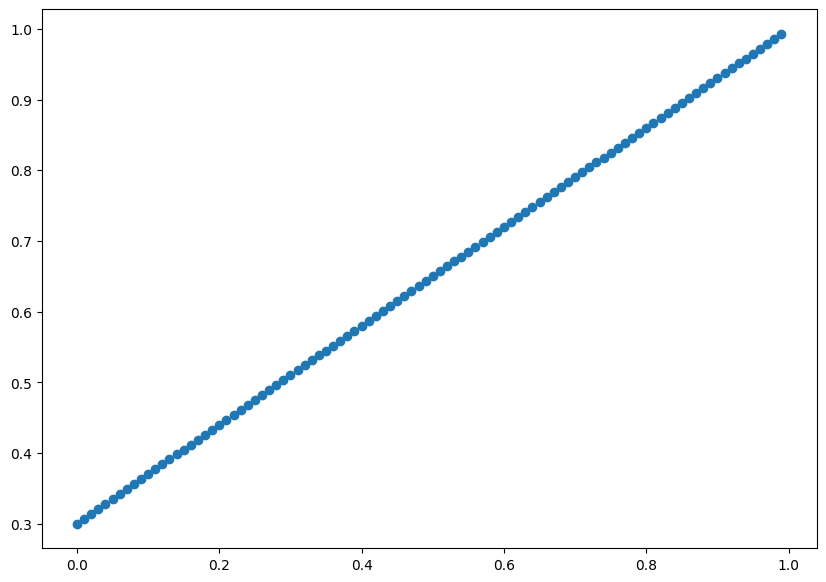

In [297]:
plt.figure(figsize=(10,7))
plt.scatter(X,y)
plt.show()

In [298]:
X_new =X
# X_new+= 0.1*torch.randn_like(X)
y_new =y+ 0.1*torch.randn_like(y)

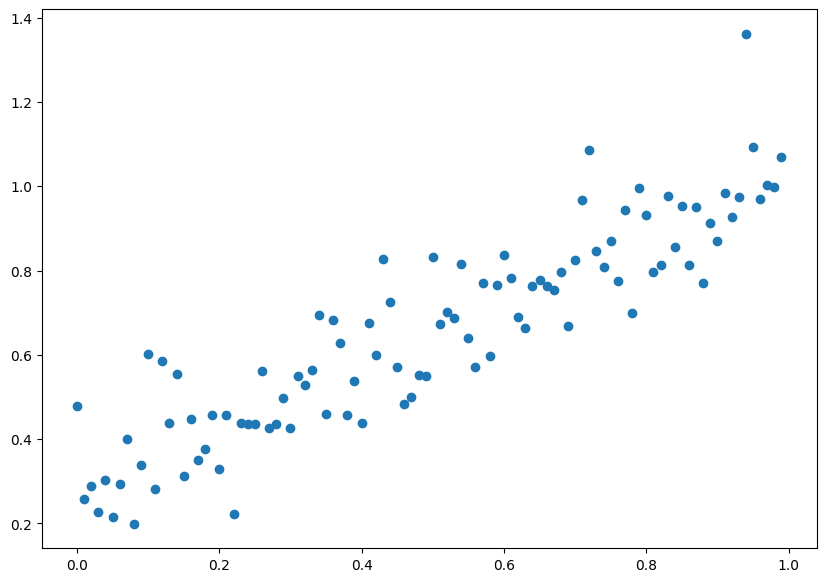

In [299]:
plt.figure(figsize=(10,7))
plt.scatter(X_new,y_new)
plt.show()

In [300]:
# X += 0.1*torch.rand_like(X)
y += 0.1*torch.rand_like(y)

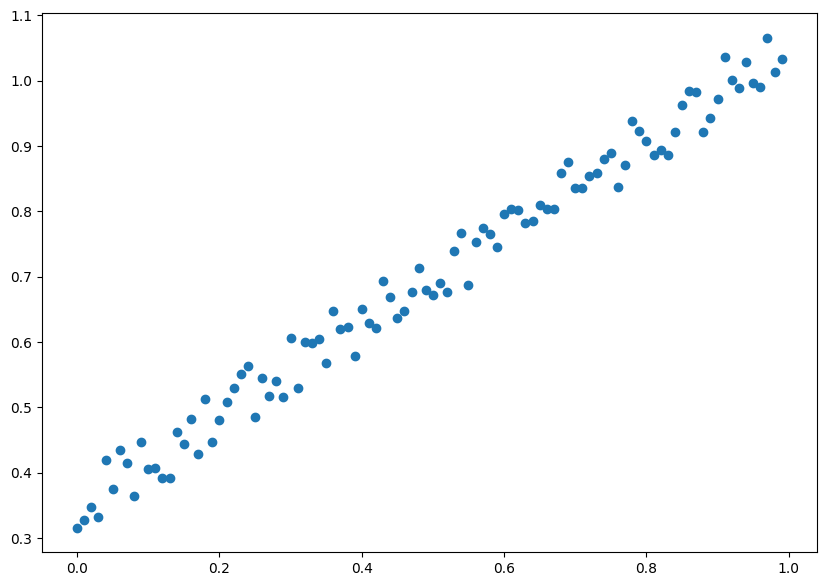

In [301]:
plt.figure(figsize=(10,7))
plt.scatter(X,y)
plt.show()

### Splitting data to train/test

In [302]:
train_split = int(0.8*len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(80, 80, 20, 20)

In [303]:
def plot_prediction(X_train=X_train, 
                    y_train=y_train,
                    X_test=X_test,
                    y_test=y_test,
                    prediction=None):

    plt.figure(figsize=(10,7))
    plt.scatter(X_train,y_train, label="Train data")
    plt.scatter(X_test,y_test, label="Test data")
    if prediction is not None :
        plt.scatter(X_test,prediction, label="Prediction")
    plt.show()

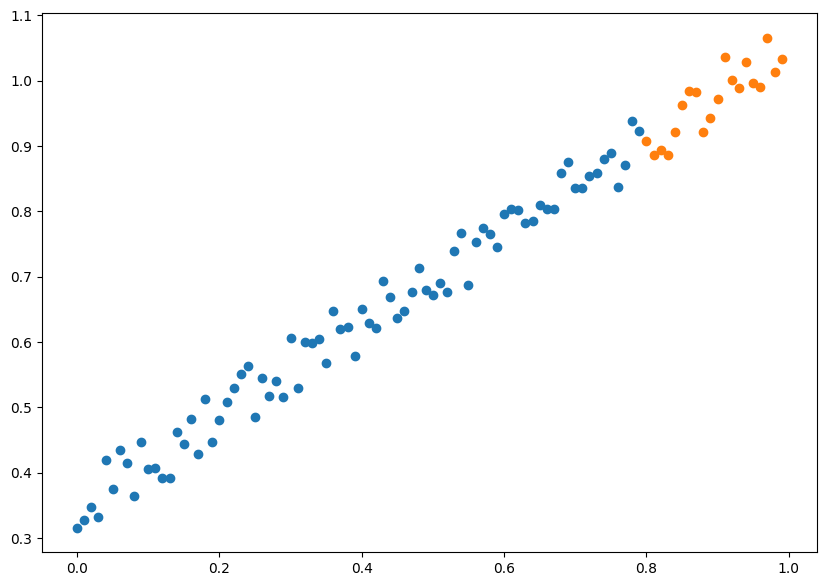

In [304]:
plot_prediction()

## 2. Build model

In [305]:
# Create linear regression model

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,
                            requires_grad=True, # Default is True
                            dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1,
                            dtype=torch.float))
                            
    # Forward method for computation in the model
    def forward(self, x:torch.Tensor):
        return self.weights* x + self.bias
    

### Checking the content of PyTorch model

In [306]:
torch.manual_seed(42)

model_0 = LinearRegressionModel()

# Check out the parameter
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [307]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Make first prediction

In [308]:
with torch.inference_mode():
    y_pred = model_0(X_test)

#### The same as torch.inference_mode()
# with torch.no_grad():
#     y_pred = model_0(X_test)

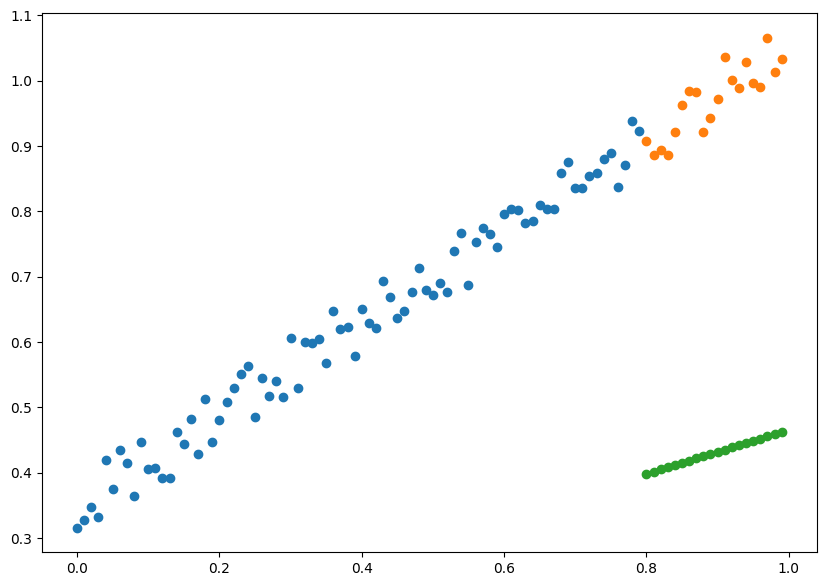

In [309]:
plot_prediction(prediction=y_pred)

## 3. Train model

In [310]:
# Setup a Loss function 
loss_fn = nn.L1Loss()

# Setup an Optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),
                        lr=0.01)

### Building a training/testing loop

In [311]:
epochs = 250 # epoch is one loop through the data

epoch_count = []
loss_values = []
test_loss_values = []
### Training
for epoch in range(epochs):
    
    # Set model to train for training option(such as Dropout, Gradient ,...)
    model_0.train()

    # 1. Forward pass
    y_pred = model_0(X_train)

    # 2. Calculate the loss
    loss = loss_fn(y_pred,y_train)
    
    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Backpropagation
    loss.backward()

    # 5. Step the optimizer
    optimizer.step() 

   
    # Test model
    model_0.eval()
    with torch.inference_mode():
        # 1. Forward pass 
        test_pred = model_0(X_test)

        # 2. Calculate the loss
        test_loss = loss_fn(test_pred,y_test)

     # Extra term for detail while training
    if epoch%10 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss)
        test_loss_values.append(test_loss)
        print(f"Epoch:{epoch} | Loss:{loss} | Test Loss:{test_loss}")
    



Epoch:0 | Loss:0.3643813729286194 | Test Loss:0.5268701314926147
Epoch:10 | Loss:0.2487788200378418 | Test Loss:0.3915175795555115
Epoch:20 | Loss:0.1341078132390976 | Test Loss:0.2571740746498108
Epoch:30 | Loss:0.06743083149194717 | Test Loss:0.15588191151618958
Epoch:40 | Loss:0.05091051384806633 | Test Loss:0.10731144994497299
Epoch:50 | Loss:0.04714196175336838 | Test Loss:0.08768298476934433
Epoch:60 | Loss:0.04469221085309982 | Test Loss:0.08050449937582016
Epoch:70 | Loss:0.04230327531695366 | Test Loss:0.07241488993167877
Epoch:80 | Loss:0.03992646187543869 | Test Loss:0.06436122953891754
Epoch:90 | Loss:0.03761526942253113 | Test Loss:0.05762147903442383
Epoch:100 | Loss:0.03563898801803589 | Test Loss:0.05099544674158096
Epoch:110 | Loss:0.033818576484918594 | Test Loss:0.045881934463977814
Epoch:120 | Loss:0.03215711563825607 | Test Loss:0.03977829962968826
Epoch:130 | Loss:0.030655035749077797 | Test Loss:0.033509571105241776
Epoch:140 | Loss:0.029504209756851196 | Test Lo

In [312]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.6763], requires_grad=True),
 Parameter containing:
 tensor([0.3646], requires_grad=True)]

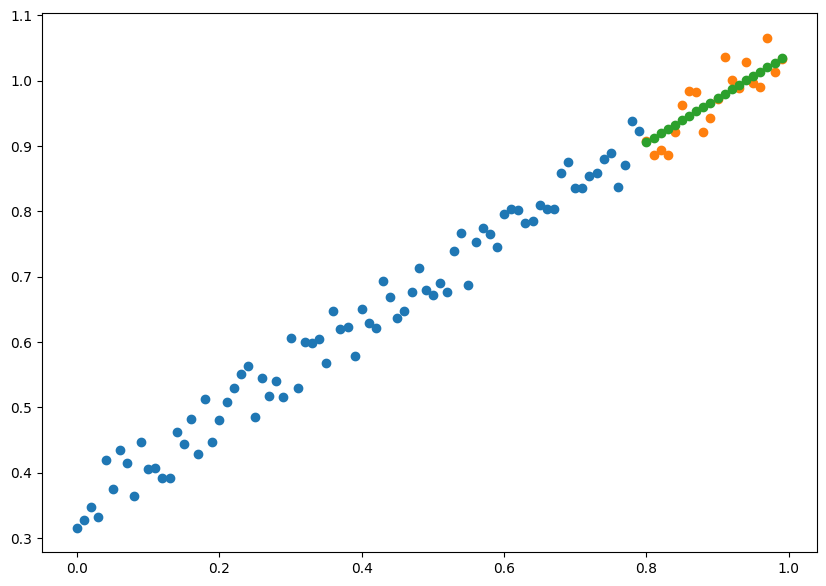

In [313]:
with torch.inference_mode():
    model_0.eval()
    y_pred = model_0(X_test)

plot_prediction(prediction=y_pred)

### Plots train/test loss

In [314]:
# Just for visualize 
loss_values = torch.tensor(loss_values).detach().clone().numpy()

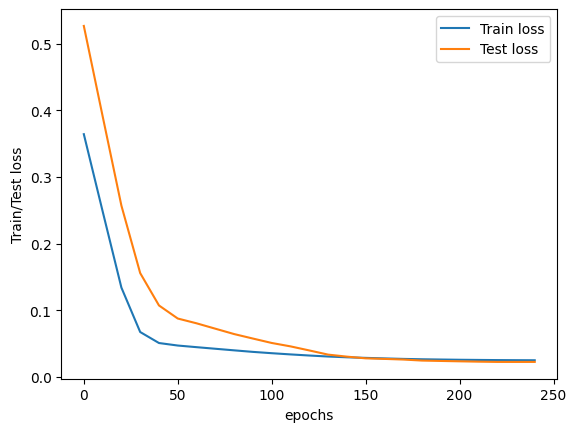

In [315]:
plt.plot(epoch_count,loss_values,label="Train loss")
plt.plot(epoch_count,test_loss_values,label="Test loss")
plt.ylabel("Train/Test loss")
plt.xlabel("epochs")
plt.legend()
plt.show()

## 4. Saving a model

In [316]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6763])), ('bias', tensor([0.3646]))])

In [317]:
# Saving model
from pathlib import Path

# Create model dir
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True,exist_ok=True)

# Create model save path
MODEL_NAME = "01_pytorch_workflow.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# Save the model state dict
print(f"Saving model to {MODEL_SAVE_PATH}")
torch.save(model_0.state_dict(),MODEL_SAVE_PATH)

Saving model to models\01_pytorch_workflow.pth


## 5. Loading a model

In [318]:
# 1. Create instance of model
loaded_model_0 = LinearRegressionModel()

loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.2345])), ('bias', tensor([0.2303]))])

In [319]:
# 2. Load saved state dict to new model
loaded_model_0.load_state_dict(torch.load(MODEL_SAVE_PATH))

loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6763])), ('bias', tensor([0.3646]))])

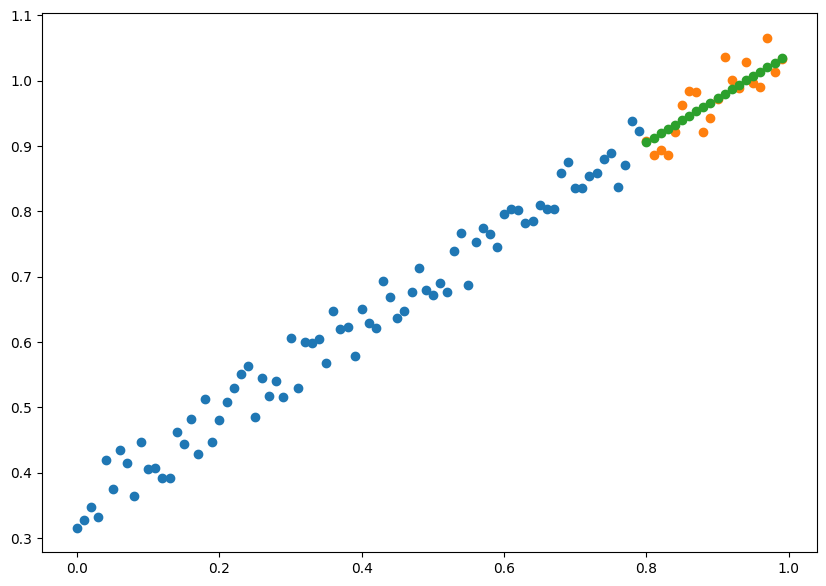

In [320]:
loaded_model_0.eval()
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(X_test)

plot_prediction(prediction=loaded_model_preds)

In [321]:
loaded_model_preds == y_pred

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

## 6. Putting it all together

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.11.0+cpu'

In [2]:
device = "cude" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")

device: cpu


### 6.1 Data

In [3]:
# Create some data y = weight * X + bias

weight = -0.6
bias = 0.1

start = 0
end = 1
step = 0.02

# Create C and y (features and labels)
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias 

# For randomnes
y += 0.1*torch.rand_like(y)

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.1624],
         [0.1300],
         [0.0767],
         [0.1219],
         [0.0765],
         [0.1394],
         [0.0488],
         [0.0249],
         [0.0645],
         [0.0710]]))

In [4]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)


(40, 40, 10, 10)

In [5]:
# Plot data
def plot_prediction(X_train=X_train, 
                    y_train=y_train,
                    X_test=X_test,
                    y_test=y_test,
                    prediction=None):

    plt.figure(figsize=(10,7))
    plt.scatter(X_train,y_train, label="Train data")
    plt.scatter(X_test,y_test, label="Test data")
    if prediction is not None :
        plt.scatter(X_test,prediction, label="Prediction")
    plt.show()

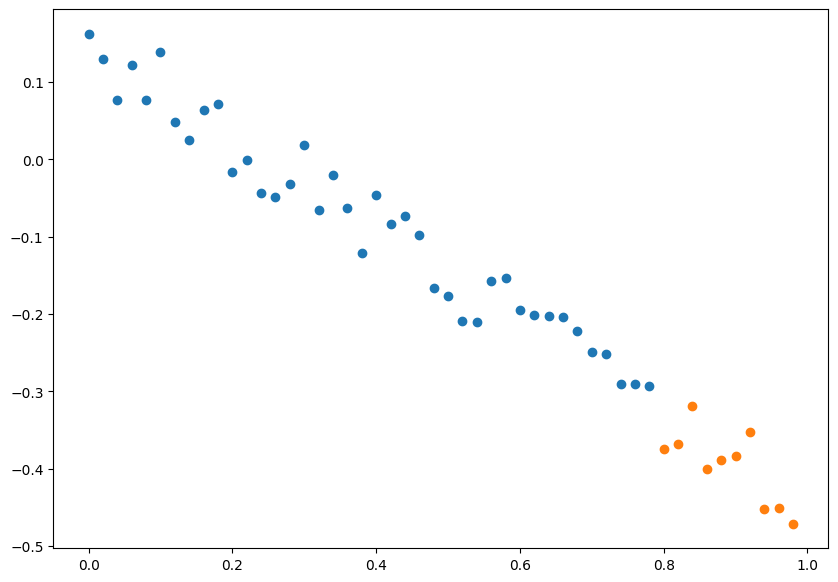

In [6]:
plot_prediction()

### 6.2 Linear model

In [28]:
class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()

        #Use nn.Linear() for creating the model parameters
        self.linear_layer = nn.Linear(in_features=1,
                                        out_features=1)
        
    
    def forward(self, x:torch.Tensor):
        return self.linear_layer(x)
    
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict() 

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [29]:
model_1.to(device)
next(model_1.parameters()).device

device(type='cpu')

### 6.3 Training

In [30]:
# Setup loss function (L2 loss)
loss_fn = nn.MSELoss()

# Setup out optimizer (Adam optimizer)
optimizer = torch.optim.Adam(model_1.parameters(),
                                lr=0.1)

In [31]:
epochs = 250

X_trian = X_train.to(device)
y_trian = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)


for epoch in range(epochs):
    model_1.train()

    # 1. Forward pass
    y_pred = model_1(X_train)

    # 2. Calculate the loss
    loss = loss_fn(y_pred, y_train)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Perform backpropagation
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_1.eval()
    with torch.inference_mode():
        test_pred = model_1(X_test)
        
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss}")
    


Epoch: 0 | Loss: 1.555137038230896 | Test Loss: 2.955979347229004
Epoch: 10 | Loss: 0.011639023199677467 | Test Loss: 0.007349963299930096
Epoch: 20 | Loss: 0.1194341629743576 | Test Loss: 0.040107712149620056
Epoch: 30 | Loss: 0.00933275930583477 | Test Loss: 0.08823089301586151
Epoch: 40 | Loss: 0.015258190222084522 | Test Loss: 0.07142653316259384
Epoch: 50 | Loss: 0.005859548691660166 | Test Loss: 0.0023014694452285767
Epoch: 60 | Loss: 0.001843365142121911 | Test Loss: 0.009619480930268764
Epoch: 70 | Loss: 0.0019361911108717322 | Test Loss: 0.01253143697977066
Epoch: 80 | Loss: 0.0011870720190927386 | Test Loss: 0.0029452538583427668
Epoch: 90 | Loss: 0.0009347649174742401 | Test Loss: 0.004107350949198008
Epoch: 100 | Loss: 0.0009197837789542973 | Test Loss: 0.003575114533305168
Epoch: 110 | Loss: 0.0009041364537551999 | Test Loss: 0.002474593697115779
Epoch: 120 | Loss: 0.0008926014415919781 | Test Loss: 0.002868989482522011
Epoch: 130 | Loss: 0.0008900162065401673 | Test Loss:

In [32]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[-0.5478]])),
             ('linear_layer.bias', tensor([0.1325]))])

### 6.4 Evaluating prediction

In [33]:
# Turn model into eval mode
model_1.eval()

# Make predictions on the test data
with torch.inference_mode():
    y_preds = model_1(X_test)
y_preds

tensor([[-0.3058],
        [-0.3167],
        [-0.3277],
        [-0.3386],
        [-0.3496],
        [-0.3605],
        [-0.3715],
        [-0.3824],
        [-0.3934],
        [-0.4044]])

In [34]:
y_test

tensor([[-0.3741],
        [-0.3676],
        [-0.3187],
        [-0.4006],
        [-0.3889],
        [-0.3838],
        [-0.3530],
        [-0.4516],
        [-0.4511],
        [-0.4711]])

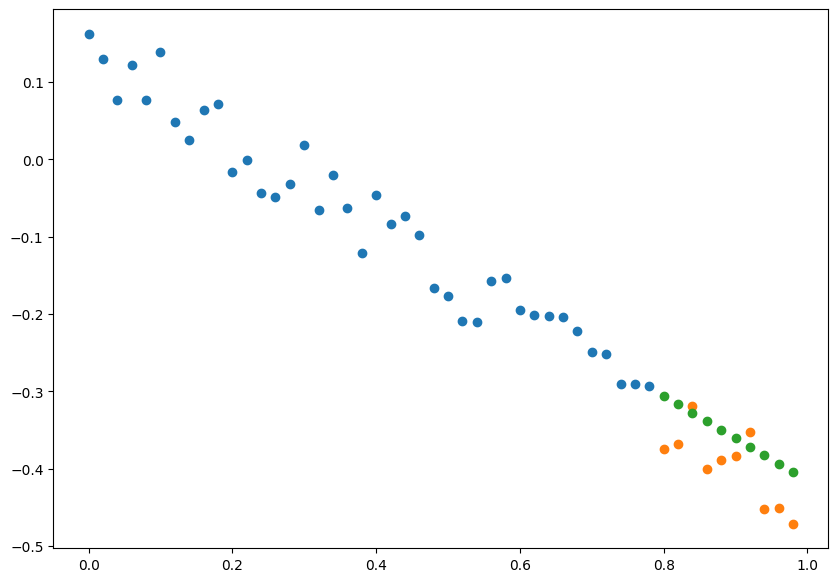

In [35]:
# Check out model prediction visually
plot_prediction(prediction=y_preds.cpu())

### 6.5 Saving & loading trained model

In [36]:
from pathlib import Path

# Create model directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# Create model save path
MODEL_NAME = "01_pytorch_workflow_model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# Save the model state dict
print(f"Saving model to:{MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(),
            f=MODEL_SAVE_PATH)



Saving model to:models\01_pytorch_workflow_model_1.pth


In [37]:
# Load a model

# Create a new instance of linear regression model v2
loaded_model_1 = LinearRegressionModelV2()

# Load the saved model_1 state dict
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))

# Put the loaded model to device 
loaded_model_1.to(device)

LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [38]:
next(loaded_model_1.parameters()).device

device(type='cpu')

In [39]:
loaded_model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[-0.5478]])),
             ('linear_layer.bias', tensor([0.1325]))])

In [ ]:
# Evaluate loaded model
loaded_model_1.eval()
with torch.inference_mode():
    loaded_model_1_preds = loaded_model_1(X_test)

loaded_model_1_preds == y_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])